# Basic Neural network

✨ Building a NN (Neural network) requires piecing together components together to perform a particular task.

**Task**: Given an (3x3) image of black and white pixels, <u>the models predicts if the image contains more white pixels than black pixels</u>. Note that there are other architectures that outperform this one for image datasets.

The network we are going to build is a **Single-Layer Perceptron** / **One-Layer Network**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.basic_nn import draw_image_cell_image, create_black_white_image_dataset

# Reloads external functions when their code changes into this notebook.
%load_ext autoreload
%autoreload 1
# %aimport will only reload those files
# %aimport utils.bboxes
%aimport utils.basic_nn

## Dataset

### Explain dataset

In [2]:
one_image, one_label = create_black_white_image_dataset(1)

In [3]:
one_image[0]

array([[0, 1, 0],
       [1, 0, 0],
       [0, 0, 1]])

An image is an array were $1$ represents a white pixel and $0$ represents black pixel.

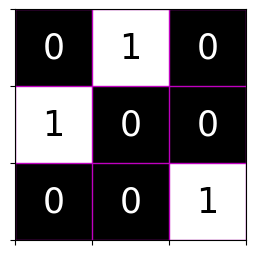

In [4]:
draw_image_cell_image(one_image[0])

In [5]:
print("⭐️ Image's label:", int(one_label[0]))

⭐️ Image's label: 0


* The **label** for that image is either **1** for there are more white pixels than black pixels and **0** otherwise.

### Create dataset

In [6]:
num_samples = 5000
images, labels = create_black_white_image_dataset(num_samples)

### Preprocess The Dataset

**Inputs And Labels:**
- Inputs can also be noted as **features** or **x**.
    - The input is the image_array
    - Each pixel is a single feature.
    - We feed the model the input.
    - The model expects a $(n, 9)$ input vector, so we also reshape the (3x3) image array into $(n, 9)$.
      - The $n$ represents how many **samples** are in the dataset, one sample is one image.

- Labels can also be noted as **target**, **ground truth** or **y**.
    - We compare the model's prediction to the label.

In [7]:
X = images.reshape( num_samples, 9)
X.shape

(5000, 9)

In [11]:
Y = labels.reshape(-1, 1) # the reshape adds an extra dimension -> , 1)
Y.shape

(5000, 1)

⭐️ **Normalize**
- For certain datasets like images, we normalize the image pixel data to be values between $[0,1]$, this allows the model to train faster and converge better.
    - Regular **grayscale** pixel values are:
        - $0$ value represents a black pixel, and $255$ value represents a white pixel.
- However, since our image data is stored as **0s and 1s**, not in pixel values, it's already in a small, stable range. We can skip normalization for this dataset.

## Create Single-Layer Perceptron Model

<p align="center">
    <img src="./showcase_images/single-layer-perceptron.png" alt="logistic regression network" width="100%">
</p>

### Network description:
- A Single-layer perceptron has no hidden layers.

- $x_1$ is the first pixel of an image, $x_9$ is the ninth pixel of the same image.
  - Each input pixel has its own corresponding weight $w_1$, $w_2$, etc..
    - Each weight determines the strength of its corresponding pixel input.

- Feed process: 
  1. Pass the images input through the network.
  2. Weighted Sum: For each output neuron, the network calculates a weighted sum of all the inputs. It multiples each input pixel by a weight then sums all as noted by $y = (x_1 w_1) + (x_2 w_2) + ... + (x_9 w_9)$.
  3. Bias: A bias is added to this sum, $Z = y + b$.
  4. Activation: The result is passed through a sigmoid activation function to produce the final output $\hat{y}$.

**Training Process:**
1. **Forward propagation:** Feed the images input to the model and calculate how the model performs (the **Loss**).
2. **Backward propagation:** Adjust model's learned parameters to make it perform better.
   1. Use the Loss to calculate gradients (how much each $w$ and $b$ contributed to the error)
   2. Update the learned parameters $(w, b)$.

### Learned Parameters

`w` (weights) & `b` (bias).
- `w:`
    -  Each weight neuron determine the importance or influence of it's corresponding pixel input on the networks's output. A large weight means that a change in the input will have a significant impact on the output.

    - Randomly initializing the weights. This is crucial to break symmetry, which ensures that each weight neuron learns a unique function.
        - We are using the [Xavier Initialization](./param_initializers/Xavier_init.ipynb), but there are other initialization algorithms such as the [He algorithm](./param_initializers/He_init.ipynb). 
        - Note: If all weights were initialized to the same value like $0$, all neurons in a layer would learn the exact same thing, making the network ineffective.

- `b:`
    - It is a constant value added to the linear combination of inputs and weights. It allows the model to shift the activation function curve to the left or right, independent of the input values. The bias essentially gives the neuron a degree of flexibility, allowing it to fire even if all inputs are zero or to not fire even if there are high inputs.
    - Bias can be initialized to be 0.

In [12]:
def init_weights_and_bias(n_in=9, n_out=1):
    """
    Initialize the weights and bias. Initializing the weights using the Xavier algorithm, set bias scalar to be zero.

    Args:
        n_in: The total number of input features/pixels.
        n_out: The total number of output neurons, since this network is just a input to output network (single-layer perceptron), meaning we have no layers, we use n_out=1 which then gets sigmoid applied to it, to get the model's output.

    returns:
        w : weights array
        b : bias scalar
    """
    # Xavier Uniform Initialization, note theres also a Xavier Normal Initialization.
    limit = np.sqrt(6 / (n_in + n_out))
    # Create the weight matrix with random values from a uniform distribution
    w = np.random.uniform(-limit, limit, size=(n_out, n_in))
    # Initialize bias (b) to zeros
    b = np.zeros((1, n_out))
    return w, b

In [13]:
w, b = init_weights_and_bias(n_in=9, n_out=1)  
w, b

(array([[ 0.27040629,  0.17494346, -0.18395335,  0.6122592 , -0.1512013 ,
          0.69210706,  0.57589752,  0.74767089,  0.49514122]]),
 array([[0.]]))

In [14]:
w.shape, b.shape

((1, 9), (1, 1))

- The weights `w` have a shape of **(1, 9)**. each weight is for a corresponding input pixel. The same set of weights is used for all images in the dataset.
  
- The bias `b` has a shape of **(1, 1)**

### Forward Propagation

**Compute:**
$$y^{(i)} = (x_1 w_1) + (x_2 w_2) + ... + (x_9 w_9)$$

$$Z^{(i)} = y + b$$

$$\hat{y}^{(i)} = \sigma(Z^{(i)})$$

* Note:
  - $^{(i)}$ means its for one example/sample:
  - $\hat{y}$ is called "y hat".

  - **Compute Linear:**
    - Multiple each pixel input by its corresponding $W$ and sum all.
    - Add a bias $b$ to the sum.

  - **Compute non-linear activation:**
    - Apply [$sigmoid()$](./activation_functions/sigmoid.ipynb) to the $Z$ to convert those (logits) scores into probabilities.
  - **Compute Loss:**
    - Use [Binary Binary Cross Entropy](./loss_functions/binary_cross_entropy_loss.ipynb)

**Compute Linear:**

In [15]:
def linear(x, w, b):
    """
    Performs the linear part of the forward pass.
    
    Args:
        x: Input data, shape (n, 9)
        w: Weights, shape (1, 9)
        b: Bias, shape (1, 1)
    """
    y = x @ w.T # The .T is to transpose the weights so that it can be applied to the x by dot product
    z = y + b
    return z

In [16]:
z = linear(X, w, b)
z

array([[ 2.43096883],
       [ 3.29801935],
       [ 0.44534975],
       ...,
       [-0.00900989],
       [ 2.53816848],
       [ 1.53841087]], shape=(5000, 1))

**Compute non-linear activation:**

- Get the predictions

In [ ]:
def sigmoid(z):
    """
    Compute the sigmoid activate function.
    Args:
        z -- a tensor of any size.
    """
    s = 1 / (1 + np.exp(-z))
    return s

In [18]:
probabilities = sigmoid(z)
probabilities

array([[0.91915855],
       [0.9643608 ],
       [0.60953303],
       ...,
       [0.49774754],
       [0.92677463],
       [0.82323359]], shape=(5000, 1))

**Compute Loss:**

In [21]:
def BCE(y_true, y_pred):
    """
    Computes Binary Cross Entropy

    Args:
        y_true: The target binary label vector (0 or 1).
        y_pred: The model's predicted probability vector.
    
    """
    epsilon = 1e-15 # Small number to prevent division by zero.
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Clip the predictions so that the if the prediction is exactly 0 or 1 it won't break the bce function.

    bce = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    print("Loss score:" , bce)

In [22]:
Loss = BCE(Y, probabilities)
Loss

Loss score: 0.7959262489941946


The closer to the Loss is to $0$ the closer the predictions match the target labels.

### Backward propagation